# Store-and-Recall: Deep e-prop Colab Run

This notebook runs the store-and-recall path for the current project plan: task example, deep-RTRL numerical gate, depth-1/depth-2 learning curves, layer-wise gradient cosine diagnostics, and delay sweeps with seed error bars.

Set `RUN_PRESET = 'colab'` in the config cell for the heavier runs. The default `smoke` preset is intentionally small so the notebook can be checked quickly.

In [3]:
from pathlib import Path
import importlib
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = "https://github.com/Yannicksaeckl/e-prop-in-deep-networks.git"
BRANCH = "main"
REPO_DIR = Path('/content/e-prop-in-deep-networks')

if IN_COLAB and REPO_URL:
    if not REPO_DIR.exists():
        subprocess.check_call(['git', 'clone', '--branch', BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        # Make sure Colab is not using an older checkout without store_recall_suite.py.
        subprocess.run(['git', '-C', str(REPO_DIR), 'fetch', 'origin', BRANCH], check=False)
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', BRANCH], check=False)


def find_project_root():
    markers = [
        Path('tasks') / 'store_and_recall.py',
        Path('experiments') / 'store_recall_suite.py',
    ]
    starts = [Path.cwd(), Path.cwd().parent, REPO_DIR]
    if Path('/content').exists():
        starts.extend(Path('/content').glob('**/e-prop-in-deep-networks'))

    seen = set()
    for start in starts:
        for candidate in [start, *start.parents]:
            candidate = candidate.resolve()
            if candidate in seen:
                continue
            seen.add(candidate)
            if all((candidate / marker).exists() for marker in markers):
                return candidate

    raise RuntimeError(
        'Could not find experiments/store_recall_suite.py. Push/pull the latest repo, '
        'or upload experiments/store_recall_suite.py next to this notebook.'
    )

PROJECT_ROOT = find_project_root()

# Runtime hotfix for older checkouts: the core repo no longer ships LIF files,
# but some __init__.py versions still import them unconditionally.
models_init = PROJECT_ROOT / 'models' / '__init__.py'
if not (PROJECT_ROOT / 'models' / 'lif_rnn.py').exists():
    models_init.write_text(
        "from models.vanilla_rnn import VanillaRNN\n"
        "from models.leaky_rnn import LeakyRNN\n"
        "from models.deep_rnn import DeepRNN\n\n"
        "__all__ = ['VanillaRNN', 'LeakyRNN', 'DeepRNN']\n",
        encoding='utf-8',
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Drop stale project modules that can shadow the local repo in a reused kernel.
for module_name in list(sys.modules):
    if module_name in {'experiments', 'tasks', 'models', 'learning_rules'} or module_name.startswith(('experiments.', 'tasks.', 'models.', 'learning_rules.')):
        sys.modules.pop(module_name, None)
importlib.invalidate_caches()

if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(PROJECT_ROOT / 'requirements.txt')])

RESULTS_DIR = PROJECT_ROOT / 'results' / 'store_recall_colab'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Has store_recall_suite:', (PROJECT_ROOT / 'experiments' / 'store_recall_suite.py').exists())
print('Experiments dir:', sorted(p.name for p in (PROJECT_ROOT / 'experiments').glob('*.py')))
print('Results dir:', RESULTS_DIR)

Project root: /content/e-prop-in-deep-networks
Has store_recall_suite: True
Experiments dir: ['__init__.py', 'deep_eprop_comparison.py', 'depth_sweep.py', 'single_layer_eprop.py', 'store_recall_suite.py']
Results dir: /content/e-prop-in-deep-networks/results/store_recall_colab


In [4]:
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import torch

def clear_project_import_cache():
    for module_name in list(sys.modules):
        if module_name in {'experiments', 'tasks', 'models', 'learning_rules'} or module_name.startswith(('experiments.', 'tasks.', 'models.', 'learning_rules.')):
            sys.modules.pop(module_name, None)
    importlib.invalidate_caches()

clear_project_import_cache()
try:
    from experiments.store_recall_suite import (
        METHOD_LABELS,
        StoreRecallConfig,
        TrainConfig,
        run_delay_training_sweep,
        run_gradient_delay_sweep,
        run_learning_curves,
        run_rtrl_gate,
        save_json,
        with_depth,
    )
except ModuleNotFoundError:
    clear_project_import_cache()
    try:
        from experiments.store_recall_suite import (
            METHOD_LABELS,
            StoreRecallConfig,
            TrainConfig,
            run_delay_training_sweep,
            run_gradient_delay_sweep,
            run_learning_curves,
            run_rtrl_gate,
            save_json,
            with_depth,
        )
    except ModuleNotFoundError:
        print('Import failed. sys.path[0]=', sys.path[0])
        print('Expected file:', PROJECT_ROOT / 'experiments' / 'store_recall_suite.py')
        print('Exists:', (PROJECT_ROOT / 'experiments' / 'store_recall_suite.py').exists())
        print('Experiments dir:', sorted(p.name for p in (PROJECT_ROOT / 'experiments').glob('*')))
        raise
from tasks.store_and_recall import generate_batch, recall_timestep

plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

Using device: cpu


In [ ]:
RUN_PRESET = 'colab'  # change to 'colab' for the full run

PRESETS = {
    'smoke': {
        'seeds': [0],
        'n_rec': 16,
        'batch_size': 16,
        'eval_batch_size': 64,
        'n_steps': 20,
        'eval_every': 5,
        'delays': [1, 2],
        'cosine_trials': 2,
        'rtrl_reps': 1,
    },
    'colab': {
        'seeds': [0, 1, 2],
        'n_rec': 64,
        'batch_size': 64,
        'eval_batch_size': 256,
        'n_steps': 1000,
        'eval_every': 50,
        'delays': [1, 2, 3, 5, 10, 20],
        'cosine_trials': 20,
        'rtrl_reps': 5,
    },
}

cfg = PRESETS[RUN_PRESET]
TASK = StoreRecallConfig(n_patterns=4, delay=2, cue_duration=1, output_duration=1)
TRAIN_BASE = TrainConfig(
    n_rec=cfg['n_rec'],
    n_layers=2,
    batch_size=cfg['batch_size'],
    eval_batch_size=cfg['eval_batch_size'],
    n_steps=cfg['n_steps'],
    eval_every=cfg['eval_every'],
    lr=1e-3,
    device=DEVICE,
    grad_clip_norm=None,
)

SEEDS = cfg['seeds']
DELAYS = cfg['delays']
METHODS = ('bptt', 'deep-eprop', 'd=0')
print(RUN_PRESET, TASK, TRAIN_BASE)

smoke StoreRecallConfig(n_patterns=4, delay=2, cue_duration=1, output_duration=1) TrainConfig(n_rec=16, n_layers=2, batch_size=16, eval_batch_size=64, n_steps=20, eval_every=5, lr=0.001, device='cpu', grad_clip_norm=None)


In [6]:
COLORS = {'bptt': '#4C78A8', 'deep-eprop': '#54A24B', 'd=0': '#E45756'}
LAYER_STYLES = {'bottom': '-', 'top': '--', 'hidden_all': ':'}

def _rows(summary, **filters):
    rows = []
    for row in summary:
        keep = True
        for key, value in filters.items():
            if row.get(key) != value:
                keep = False
                break
        if keep:
            rows.append(row)
    return rows

def plot_learning_summary(summary, title):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for row in sorted(summary, key=lambda r: (r['depth'], r['method'])):
        steps = np.asarray(row['steps'])
        mean = np.asarray(row['accuracy_mean'])
        err = np.asarray(row['accuracy_stderr'])
        method = row['method']
        label = f"{row['method_label']} L={row['depth']}"
        ax.plot(steps, mean, label=label, color=COLORS.get(method), marker='o', markersize=3)
        ax.fill_between(steps, mean - err, mean + err, color=COLORS.get(method), alpha=0.16, linewidth=0)
    ax.axhline(TASK.chance, color='0.35', linestyle='--', linewidth=1, label='chance')
    ax.set_xlabel('Training step')
    ax.set_ylabel('Held-out accuracy')
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax

def plot_alignment_summary(summary, title, layers=('bottom', 'top', 'hidden_all')):
    fig, axes = plt.subplots(1, len(layers), figsize=(5.2 * len(layers), 4.2), sharey=True)
    if len(layers) == 1:
        axes = [axes]
    for ax, layer in zip(axes, layers):
        for method in ('deep-eprop', 'd=0'):
            rows = [r for r in summary if r['trained_method'] == method and r['approx_method'] == method and r['layer'] == layer]
            rows = sorted(rows, key=lambda r: r['step'])
            if not rows:
                continue
            steps = np.asarray([r['step'] for r in rows])
            mean = np.asarray([r['cosine_mean'] for r in rows])
            err = np.asarray([r['cosine_stderr'] for r in rows])
            ax.plot(steps, mean, label=METHOD_LABELS[method], color=COLORS[method], marker='o', markersize=3)
            ax.fill_between(steps, mean - err, mean + err, color=COLORS[method], alpha=0.16, linewidth=0)
        ax.axhline(0.0, color='0.35', linestyle=':', linewidth=1)
        ax.set_xlabel('Training step')
        ax.set_title(layer)
    axes[0].set_ylabel('Gradient cosine vs BPTT')
    axes[-1].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes

def plot_gradient_delay_summary(summary, title, layers=('bottom', 'top', 'hidden_all')):
    fig, axes = plt.subplots(1, len(layers), figsize=(5.2 * len(layers), 4.2), sharey=True)
    if len(layers) == 1:
        axes = [axes]
    for ax, layer in zip(axes, layers):
        for method in ('deep-eprop', 'd=0'):
            rows = [r for r in summary if r['method'] == method and r['layer'] == layer]
            rows = sorted(rows, key=lambda r: r['delay'])
            if not rows:
                continue
            delays = np.asarray([r['delay'] for r in rows])
            mean = np.asarray([r['cosine_mean'] for r in rows])
            err = np.asarray([r['cosine_stderr'] for r in rows])
            ax.errorbar(delays, mean, yerr=err, label=METHOD_LABELS[method], color=COLORS[method], marker='o', capsize=3)
        ax.axhline(0.0, color='0.35', linestyle=':', linewidth=1)
        ax.set_xlabel('Delay')
        ax.set_title(layer)
    axes[0].set_ylabel('Gradient cosine vs BPTT')
    axes[-1].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes

def plot_delay_final_accuracy(summary, title):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for method in METHODS:
        rows = [r for r in summary if r['method'] == method and r['depth'] == TRAIN_BASE.n_layers]
        rows = sorted(rows, key=lambda r: r['delay'])
        if not rows:
            continue
        delays = np.asarray([r['delay'] for r in rows])
        mean = np.asarray([r['final_accuracy_mean'] for r in rows])
        err = np.asarray([r['final_accuracy_stderr'] for r in rows])
        ax.errorbar(delays, mean, yerr=err, label=METHOD_LABELS[method], color=COLORS[method], marker='o', capsize=3)
    ax.axhline(TASK.chance, color='0.35', linestyle='--', linewidth=1, label='chance')
    ax.set_xlabel('Delay')
    ax.set_ylabel('Final held-out accuracy')
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax

## Task Example

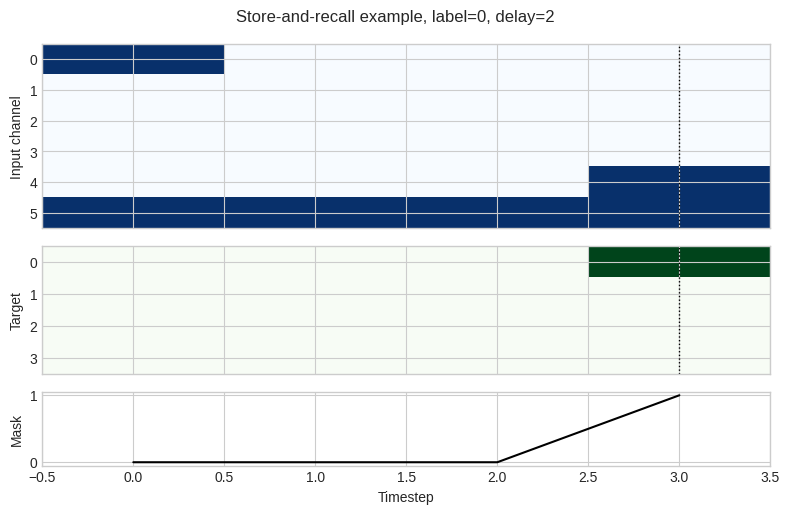

In [7]:
example_inputs, example_targets, example_mask, labels = generate_batch(
    batch_size=1,
    n_patterns=TASK.n_patterns,
    delay=TASK.delay,
    cue_duration=TASK.cue_duration,
    output_duration=TASK.output_duration,
    seed=0,
    return_labels=True,
)
recall_t = recall_timestep(TASK.delay, TASK.cue_duration)

fig, axes = plt.subplots(3, 1, figsize=(8, 5.2), sharex=True, gridspec_kw={'height_ratios': [2.0, 1.4, 0.8]})
axes[0].imshow(example_inputs[:, 0, :].T, aspect='auto', interpolation='nearest', cmap='Blues')
axes[0].set_ylabel('Input channel')
axes[0].axvline(recall_t, color='black', linestyle=':', linewidth=1)
axes[1].imshow(example_targets[:, 0, :].T, aspect='auto', interpolation='nearest', cmap='Greens')
axes[1].set_ylabel('Target')
axes[1].axvline(recall_t, color='black', linestyle=':', linewidth=1)
axes[2].plot(example_mask[:, 0].numpy(), color='black')
axes[2].set_ylabel('Mask')
axes[2].set_xlabel('Timestep')
axes[2].set_ylim(-0.05, 1.05)
fig.suptitle(f'Store-and-recall example, label={int(labels[0])}, delay={TASK.delay}')
fig.tight_layout()
fig.savefig(RESULTS_DIR / f'task_example_{RUN_PRESET}.svg')

## G2 Numerical Gate: deep-RTRL == BPTT

In [8]:
gate = run_rtrl_gate(
    n_reps=cfg['rtrl_reps'],
    seed=0,
    task=TASK,
    n_rec=8 if RUN_PRESET == 'colab' else 4,
    batch_size=4 if RUN_PRESET == 'colab' else 2,
    device='cpu',
)
save_json(gate, RESULTS_DIR / f'rtrl_gate_{RUN_PRESET}.json')
print(f"passed={gate['passed']}  max_abs={gate['max_abs']:.3e}  max_rel={gate['max_rel']:.3e}")

passed=True  max_abs=1.788e-07  max_rel=3.297e-07


## Depth-1 Reproduction Check

[BPTT] seed=0 step=0 acc=0.250
[BPTT] seed=0 step=5 acc=0.250 loss=1.1263
[BPTT] seed=0 step=10 acc=0.266 loss=0.9925
[BPTT] seed=0 step=15 acc=0.188 loss=0.9993
[BPTT] seed=0 step=20 acc=0.297 loss=0.8995
[Deep e-prop] seed=0 step=0 acc=0.250
[Deep e-prop] seed=0 step=5 acc=0.250 loss=1.1287
[Deep e-prop] seed=0 step=10 acc=0.266 loss=0.9970
[Deep e-prop] seed=0 step=15 acc=0.188 loss=1.0062
[Deep e-prop] seed=0 step=20 acc=0.297 loss=0.9062
[d=0] seed=0 step=0 acc=0.250
[d=0] seed=0 step=5 acc=0.250 loss=1.1297
[d=0] seed=0 step=10 acc=0.266 loss=0.9986
[d=0] seed=0 step=15 acc=0.188 loss=1.0083
[d=0] seed=0 step=20 acc=0.297 loss=0.9098


(<Figure size 1040x420 with 2 Axes>,
 array([<Axes: title={'center': 'bottom'}, xlabel='Training step', ylabel='Gradient cosine vs BPTT'>,
        <Axes: title={'center': 'hidden_all'}, xlabel='Training step'>],
       dtype=object))

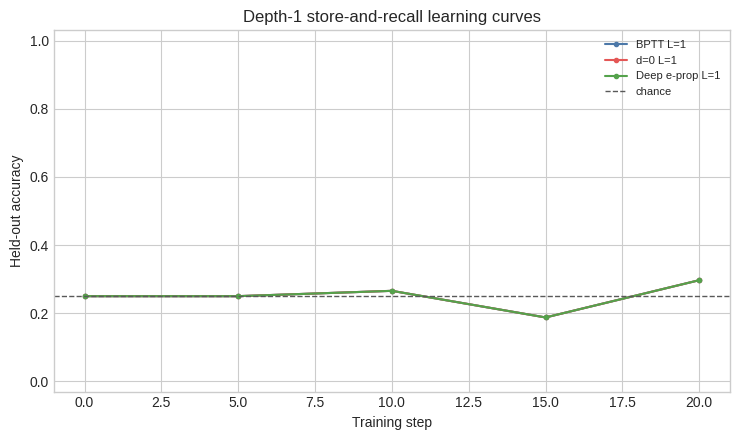

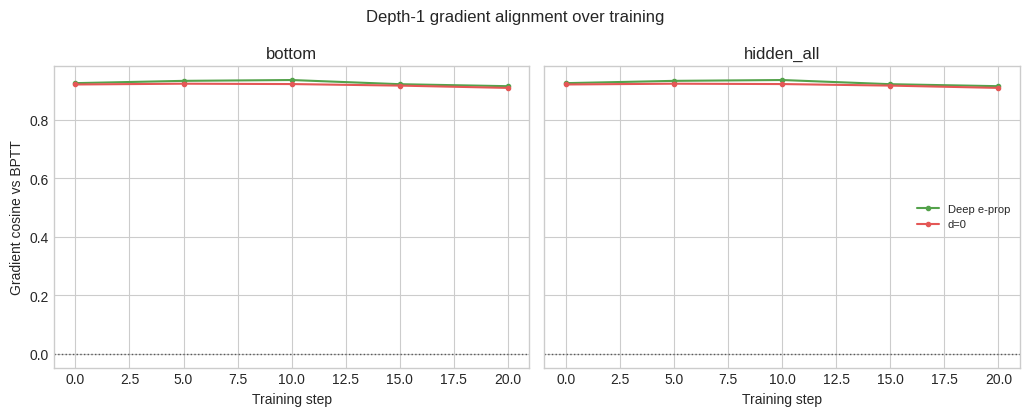

In [9]:
depth1_train = with_depth(TRAIN_BASE, 1)
depth1_result = run_learning_curves(
    methods=METHODS,
    seeds=SEEDS,
    task=TASK,
    train=depth1_train,
    track_alignment_for=('deep-eprop', 'd=0'),
    verbose=True,
)
save_json(depth1_result, RESULTS_DIR / f'depth1_learning_{RUN_PRESET}.json')
plot_learning_summary(depth1_result['summary'], 'Depth-1 store-and-recall learning curves')
plot_alignment_summary(depth1_result['alignment_summary'], 'Depth-1 gradient alignment over training', layers=('bottom', 'hidden_all'))

## Depth-2 Core Comparison

[BPTT] seed=0 step=0 acc=0.234
[BPTT] seed=0 step=5 acc=0.297 loss=0.9033
[BPTT] seed=0 step=10 acc=0.219 loss=0.8477
[BPTT] seed=0 step=15 acc=0.234 loss=0.7233
[BPTT] seed=0 step=20 acc=0.234 loss=0.7076
[Deep e-prop] seed=0 step=0 acc=0.234
[Deep e-prop] seed=0 step=5 acc=0.297 loss=0.9143
[Deep e-prop] seed=0 step=10 acc=0.219 loss=0.8688
[Deep e-prop] seed=0 step=15 acc=0.234 loss=0.7546
[Deep e-prop] seed=0 step=20 acc=0.234 loss=0.7446
[d=0] seed=0 step=0 acc=0.234
[d=0] seed=0 step=5 acc=0.297 loss=0.9166
[d=0] seed=0 step=10 acc=0.219 loss=0.8740
[d=0] seed=0 step=15 acc=0.234 loss=0.7622
[d=0] seed=0 step=20 acc=0.234 loss=0.7536


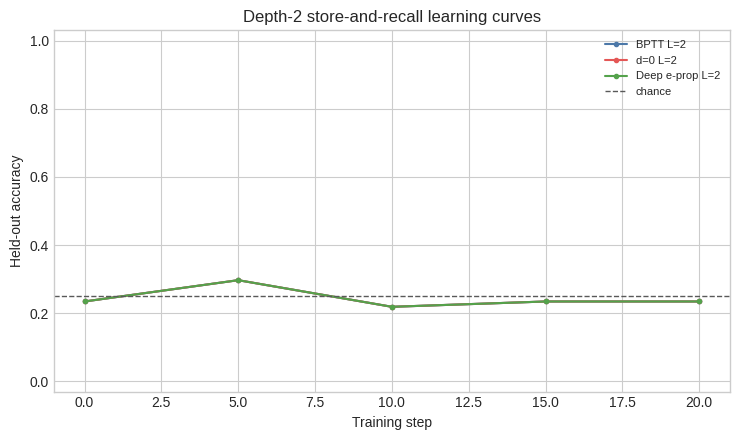

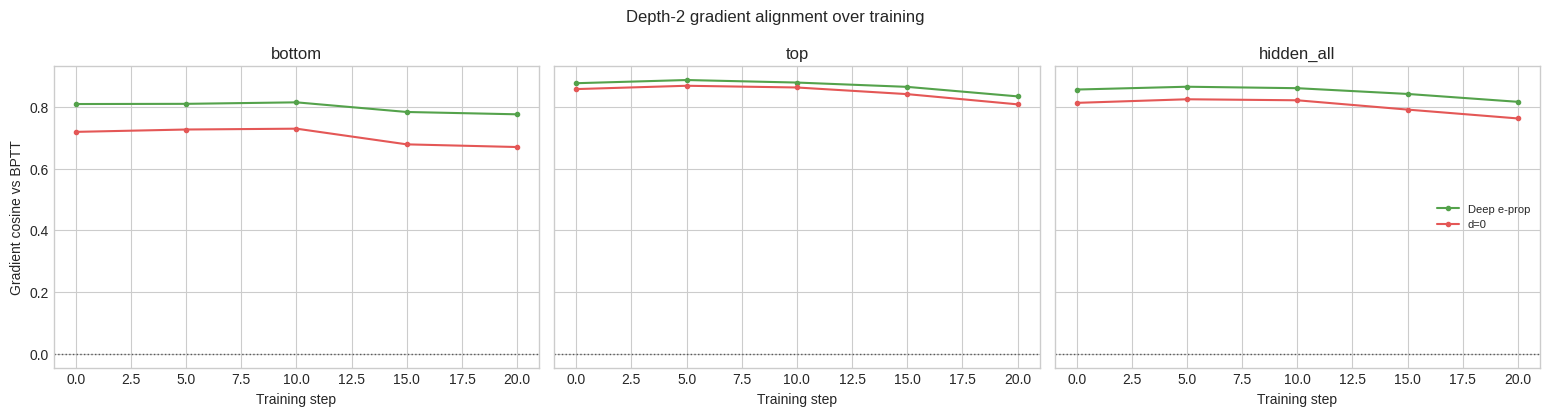

In [10]:
core_result = run_learning_curves(
    methods=METHODS,
    seeds=SEEDS,
    task=TASK,
    train=TRAIN_BASE,
    track_alignment_for=('deep-eprop', 'd=0'),
    verbose=True,
)
save_json(core_result, RESULTS_DIR / f'depth2_core_{RUN_PRESET}.json')
fig, _ = plot_learning_summary(core_result['summary'], 'Depth-2 store-and-recall learning curves')
fig.savefig(RESULTS_DIR / f'depth2_learning_{RUN_PRESET}.svg')
fig, _ = plot_alignment_summary(core_result['alignment_summary'], 'Depth-2 gradient alignment over training')
fig.savefig(RESULTS_DIR / f'depth2_alignment_over_training_{RUN_PRESET}.svg')

## Gradient Cosine vs Delay

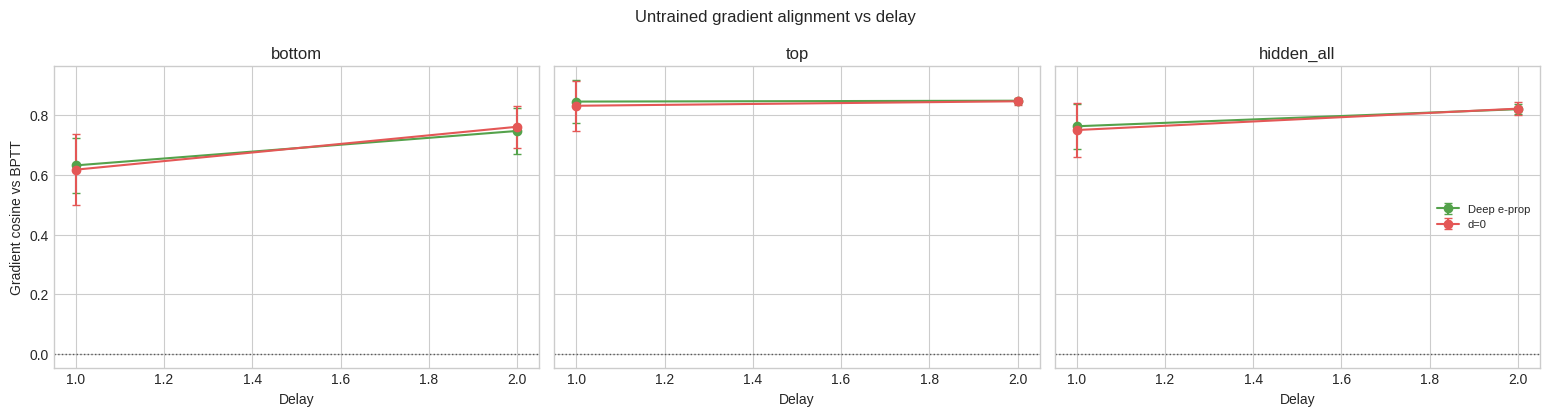

In [11]:
gradient_sweep = run_gradient_delay_sweep(
    delays=DELAYS,
    methods=('deep-eprop', 'd=0'),
    n_trials=cfg['cosine_trials'],
    seed=0,
    task=TASK,
    train=TRAIN_BASE,
)
save_json(gradient_sweep, RESULTS_DIR / f'gradient_delay_sweep_{RUN_PRESET}.json')
fig, _ = plot_gradient_delay_summary(gradient_sweep['summary'], 'Untrained gradient alignment vs delay')
fig.savefig(RESULTS_DIR / f'gradient_delay_sweep_{RUN_PRESET}.svg')

## Training Delay Sweep

[BPTT] seed=0 step=0 acc=0.516
[BPTT] seed=0 step=5 acc=0.500 loss=1.0540
[BPTT] seed=0 step=10 acc=0.500 loss=0.9689
[BPTT] seed=0 step=15 acc=0.531 loss=0.8497
[BPTT] seed=0 step=20 acc=0.422 loss=0.8956
[Deep e-prop] seed=0 step=0 acc=0.516
[Deep e-prop] seed=0 step=5 acc=0.500 loss=1.0652
[Deep e-prop] seed=0 step=10 acc=0.500 loss=0.9884
[Deep e-prop] seed=0 step=15 acc=0.531 loss=0.8757
[Deep e-prop] seed=0 step=20 acc=0.422 loss=0.9289
[d=0] seed=0 step=0 acc=0.516
[d=0] seed=0 step=5 acc=0.500 loss=1.0660
[d=0] seed=0 step=10 acc=0.500 loss=0.9903
[d=0] seed=0 step=15 acc=0.531 loss=0.8785
[d=0] seed=0 step=20 acc=0.422 loss=0.9320
[BPTT] seed=0 step=0 acc=0.234
[BPTT] seed=0 step=5 acc=0.297 loss=0.9033
[BPTT] seed=0 step=10 acc=0.219 loss=0.8477
[BPTT] seed=0 step=15 acc=0.234 loss=0.7233
[BPTT] seed=0 step=20 acc=0.234 loss=0.7076
[Deep e-prop] seed=0 step=0 acc=0.234
[Deep e-prop] seed=0 step=5 acc=0.297 loss=0.9143
[Deep e-prop] seed=0 step=10 acc=0.219 loss=0.8688
[Deep e

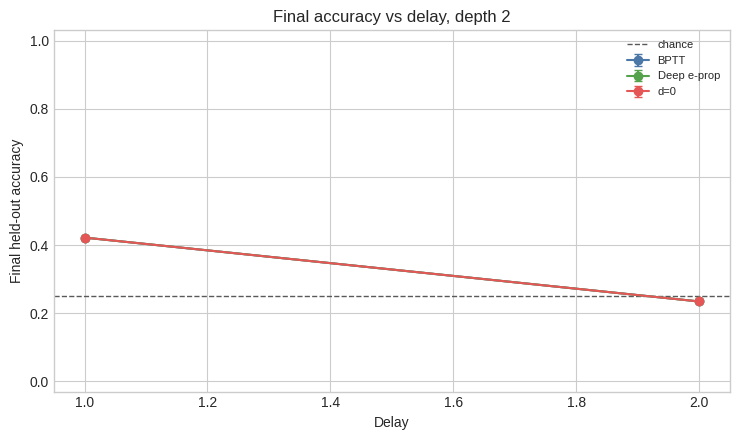

In [12]:
delay_training = run_delay_training_sweep(
    delays=DELAYS,
    methods=METHODS,
    seeds=SEEDS,
    task=TASK,
    train=TRAIN_BASE,
    verbose=True,
)
save_json(delay_training, RESULTS_DIR / f'delay_training_sweep_{RUN_PRESET}.json')
fig, _ = plot_delay_final_accuracy(delay_training['summary'], 'Final accuracy vs delay, depth 2')
fig.savefig(RESULTS_DIR / f'delay_training_sweep_{RUN_PRESET}.svg')

## Compact Result Tables

In [13]:
print('Depth-2 final accuracy:')
for row in core_result['summary']:
    print(
        f"  {row['method_label']:12s} L={row['depth']} delay={row['delay']}: "
        f"acc={row['final_accuracy_mean']:.3f} +/- {row['final_accuracy_stderr']:.3f}, "
        f"loss={row['final_loss_mean']:.4f}"
    )

print('\nBottom-layer cosine at final tracked step:')
for method in ('deep-eprop', 'd=0'):
    rows = [
        r for r in core_result['alignment_summary']
        if r['trained_method'] == method and r['approx_method'] == method and r['layer'] == 'bottom'
    ]
    rows = sorted(rows, key=lambda r: r['step'])
    if rows:
        row = rows[-1]
        print(f"  {METHOD_LABELS[method]:12s}: cos={row['cosine_mean']:.3f} +/- {row['cosine_stderr']:.3f}")

print('\nSaved artifacts:')
for path in sorted(RESULTS_DIR.glob(f'*_{RUN_PRESET}.*')):
    print(' ', path.relative_to(PROJECT_ROOT))

Depth-2 final accuracy:
  BPTT         L=2 delay=2: acc=0.234 +/- 0.000, loss=0.7076
  d=0          L=2 delay=2: acc=0.234 +/- 0.000, loss=0.7536
  Deep e-prop  L=2 delay=2: acc=0.234 +/- 0.000, loss=0.7446

Bottom-layer cosine at final tracked step:
  Deep e-prop : cos=0.775 +/- 0.000
  d=0         : cos=0.670 +/- 0.000

Saved artifacts:
  results/store_recall_colab/delay_training_sweep_smoke.json
  results/store_recall_colab/delay_training_sweep_smoke.svg
  results/store_recall_colab/depth1_learning_smoke.json
  results/store_recall_colab/depth2_alignment_over_training_smoke.svg
  results/store_recall_colab/depth2_core_smoke.json
  results/store_recall_colab/depth2_learning_smoke.svg
  results/store_recall_colab/gradient_delay_sweep_smoke.json
  results/store_recall_colab/gradient_delay_sweep_smoke.svg
  results/store_recall_colab/rtrl_gate_smoke.json
  results/store_recall_colab/task_example_smoke.svg
